In [161]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv('data/lyrics_10k.csv',index_col=0)

In [163]:
df.head()

,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,['Beth Hart'],False,modern blues,Better than home Lyrics I can feel my body bre...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,['Cypress Hill'],True,chicano rap;gangster rap;hardcore hip hop;hip ...,Illusions Lyrics Some people tell me that I ne...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,['Brandi Carlile'],False,acoustic pop;folk;indie pop;lilith;modern folk...,Touching the Ground Lyrics I swear when we tou...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,['Big Sean'],True,detroit hip hop;hip hop;pop;pop rap;rap;southe...,Nothing Is Stopping You Lyrics Nothing is stop...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,['Sheryl Crow'],False,lilith;mellow gold;neo mellow;new wave pop;per...,I Shall Believe Lyrics Come to me now And lay ...


In [164]:
df[df['lyrics'].str.contains('Embed')].iloc[0]['lyrics']

"Better than home Lyrics I can feel my body breathing I can feel my heart is moving fast I am not afraid or lonely I am not chasing the ghosts of the past I have found the place where hunger Meets the edge and now I'm facing God I won't dare look into his eyes I can only hang my head to the ground When I try and open my mouth There's so many words but there's no sound And the angel comes upon me And the love I feel's a love I've never known And it's better than home Better than home Out on this long and winding road Chasing the sound with my friends And we ain't never rolling back again And who knows what we're gonna find Knows what we're gonna see Knows how we're gonna change Knows what we're gonna be Baby it's just you and me So keep driving on Cause this is better than home Everything inside me is stirring In every corner of every secret wound In the light I am adoring Feel like flying in circles around the moon When I gaze upon the world I know that I'm a part of something good I k

In [165]:
df.shape

(8674, 7)

## Дубликаты

In [166]:
df.duplicated().sum()

np.int64(0)

но этот 0 может означать только то, что у нас нет полных дубликатов (строчки, у которых совпадают абсолютно все признаки). Надо посмотреть дубликаты по названиям песни или название песни + артист. Важно выбрать именно второй вариант - так как существуют песни с одинаковым названием у разных исполнителей (например - Hello есть у Adele, Lionel Richie, Martin Solveig, Eminem и Evanescence)

In [167]:
df[['song','artists']].duplicated().sum()

np.int64(1996)

вот и ловушка метода duplicated с дефолтными параметрами - у нас аж 1990 потенциальных дубликатов.

In [168]:
duplicats = df[df[['song','artists']].duplicated(keep=False)].sort_values('song')
duplicats

,song_id,artist_id,song,artists,explicit,genres,lyrics
5163,spotify:track:2S62u9h7ea1zxstVQWFaA5,spotify:artist:1Yox196W7bzVNZI7RBaPnf,1000 Times Goodbye,['Megadeth'],False,alternative metal;hard rock;melodic thrash;met...,1000 Times Goodbye Lyrics The tides of change ...
1305,spotify:track:2EW8oHPex1xcGOTLcjgAhq,spotify:artist:1Yox196W7bzVNZI7RBaPnf,1000 Times Goodbye,['Megadeth'],False,alternative metal;hard rock;melodic thrash;met...,1000 Times Goodbye Lyrics The tides of change ...
4347,spotify:track:63pDgNA2K9O5NY9SathH0q,spotify:artist:26T3LtbuGT1Fu9m0eRq5X3,2024,['Cage The Elephant'],False,modern rock;punk blues;rock,2024 Lyrics Fall into that black hole honey L...
5334,spotify:track:1YpeognS6DsZSi8qx1U4Ya,spotify:artist:26T3LtbuGT1Fu9m0eRq5X3,2024,['Cage The Elephant'],False,modern rock;punk blues;rock,2024 Lyrics Fall into that black hole honey L...
8354,spotify:track:56fXFvwIGDLvWFhuZtWhrO,spotify:artist:3q7HBObVc0L8jNeTe5Gofh,21 Questions,"['50 Cent', 'Nate Dogg']",True,east coast hip hop;gangster rap;hip hop;pop ra...,Translations Русский Português50 Cent - 21 Que...
...,...,...,...,...,...,...,...
8565,spotify:track:4tnv9cIytZz1eLgdi8wfuQ,spotify:artist:06HL4z0CvFAxyc27GXpf02,this is me trying,['Taylor Swift'],False,pop,Translations Nederlands Türkçe Español Српски ...
324,spotify:track:5U0MyuuCoOoniHLQFLazLF,spotify:artist:06HL4z0CvFAxyc27GXpf02,tolerate it,['Taylor Swift'],False,pop,Translations Türkçe Español Română Português I...
876,spotify:track:4wKsj88mt0ZRKCmOx8BRlu,spotify:artist:06HL4z0CvFAxyc27GXpf02,tolerate it,['Taylor Swift'],True,pop,Translations Türkçe Español Română Português I...
5875,spotify:track:2rtvt2O0Ypg6VL4tUgxnB6,spotify:artist:06HL4z0CvFAxyc27GXpf02,willow,['Taylor Swift'],False,pop,Translations Türkçe Español Српски Română Port...


In [169]:
df[['song','explicit','genres','lyrics']].duplicated().sum()

np.int64(1603)

Было предположение, что эти дубликаты отличаются только по id - однако не все (только 1598 из 1990 поддаются этой логике).

In [170]:
duplicats_diff = duplicats[['song','explicit','genres','lyrics']].groupby('song').nunique()
duplicats_diff

,explicit,genres,lyrics
song,,,
1000 Times Goodbye,1,1,1
2024,1,1,1
21 Questions,2,1,1
24K Magic,1,1,2
2step,1,1,1
...,...,...,...
the 1,1,1,2
the last great american dynasty,2,1,2
this is me trying,1,1,1


In [171]:
duplicats_diff.max()

explicit    2
genres      5
lyrics      6
dtype: int64

то есть различия в дубликатах могут быть по всем колонкам, кроме explicit

In [172]:
duplicats_diff[duplicats_diff.max(axis=1)>1]

,explicit,genres,lyrics
song,,,
21 Questions,2,1,1
24K Magic,1,1,2
32-20 Blues,1,1,2
36,2,1,1
4KT Baby,2,1,1
...,...,...,...
pick up the phone,2,1,1
skin,1,1,2
the 1,1,1,2


In [173]:
duplicats_count = duplicats.groupby(['song','artists'])['song_id'].count()
duplicats_count

song                             artists                 
1000 Times Goodbye               ['Megadeth']                2
2024                             ['Cage The Elephant']       2
21 Questions                     ['50 Cent', 'Nate Dogg']    2
24K Magic                        ['Bruno Mars']              2
2step                            ['Ed Sheeran']              8
                                                            ..
the 1                            ['Taylor Swift']            2
the last great american dynasty  ['Taylor Swift']            2
this is me trying                ['Taylor Swift']            2
tolerate it                      ['Taylor Swift']            2
willow                           ['Taylor Swift']            2
Name: song_id, Length: 1460, dtype: int64

In [174]:
duplicats_count.max() # максимальное кол-во дубликатов

np.int64(9)

In [175]:
duplicats_count[duplicats_count==duplicats_count.max()]

song      artists             
Bonita    ['GIMS']                9
Clap      ['Armin van Buuren']    9
Tant pis  ['GIMS']                9
Name: song_id, dtype: int64

In [176]:
duplicats_diff[duplicats_diff['genres']>duplicats_diff['lyrics']]

,explicit,genres,lyrics
song,,,


In [177]:
duplicats_diff[duplicats_diff['genres']<duplicats_diff['lyrics']]

,explicit,genres,lyrics
song,,,
24K Magic,1,1,2
32-20 Blues,1,1,2
A Change Would Do You Good,1,1,2
A Milli,1,1,2
ABOUT YOU,2,1,2
...,...,...,...
mirrorball,1,1,2
skin,1,1,2
the 1,1,1,2


Почему так получилось, что у нас одна и та же песня могла попасть в датасет несколько раза и с разными айдишниками?
Предположения:
- песня внутри альбома, сборника или в поиске - разные цифровые объекты, которые как раз и отличаются только по id. Это проблемы парсинга
- разные правила на дистрибуцию музыки в разных регионах - следовательно под каждый регион создается свой цифровой объект песни с нужными правами

Почему так получилось, что у нас одна и та же песня могла попасть в датасет несколько раза и с разными жанрами?
Ответ: вспомним тот пример с песней Hello - с таким названием есть треки у многих - то есть это все же разные песни (то есь они и текстом отличаются и жанром).

Также выследилось правило: количество песен в жанре меньше или равно количеству по тексту. Почему?
Мы прибегаем к второму пункты первого вопроса: разные регионы - разные правила, то есть разная цензура.

В итоге - мы удаляем песни-дубликаты ВСЕ. Оставляем только первое вхождение песни, у которой есть дубликат (это одна из версий песни для какого-то региона)

In [178]:
df.shape

(8674, 7)

In [179]:
df = df[~df[['song','artists']].duplicated()]

In [180]:
df.shape

(6678, 7)

## Пропуски

In [181]:
df.isna().sum()

song_id       0
artist_id     0
song          0
artists       0
explicit      0
genres       55
lyrics        0
dtype: int64

## Анализ жанров

In [182]:
df[df['genres'].isna()]

,song_id,artist_id,song,artists,explicit,genres,lyrics
176,spotify:track:3pf9eIGYFtIlL2UnJqFsrG,spotify:artist:0KuF7reCTOZwV7YJnHQqgr,Intro,['The Neptunes'],True,NaN,Intro Lyrics1 2 3 41 2 3 41 2 3 4 1C...
214,spotify:track:5SDIN7Z1SZMdRYVpx7abaA,spotify:artist:7n5xb6bByE74Aw4ppe858H,For Chan,['Tim Heidecker'],False,NaN,For Chan Lyrics I am only one man but my words...
266,spotify:track:6Jln2IgzM0RGlqZy9Igx1W,spotify:artist:4gKo3LXoxHriLS6CBKThAU,Touch the Sky,"['MALINDA', {'label': 'spotify:artist:3peB3IJ4...",False,NaN,Touch the Sky Lyrics When the cold wind is a-c...
550,spotify:track:6l2JdUq3mM5F1pwXQ6uZaT,spotify:artist:1hckaudcoOzWyeRIlrOksc,Shut Up,['Kelly Osbourne'],False,NaN,Shut Up Lyrics You say I should do it differen...
688,spotify:track:1lCNiqX329mUgg9b8UXyCY,spotify:artist:7n5xb6bByE74Aw4ppe858H,Get Back Down To Me,['Tim Heidecker'],False,NaN,Get Back Down To Me Lyrics Take that One two ...
690,spotify:track:4maOMwEZYIdR14tiRM716c,spotify:artist:0xHewD1ry8hiwjBgZdNcU3,Love Me,['LEEX'],False,NaN,Love Me Lyrics You tell me that you love me Th...
762,spotify:track:1xlsT9Jn1aQvXfG3BxsBzM,spotify:artist:7n5xb6bByE74Aw4ppe858H,In Glendale,['Tim Heidecker'],False,NaN,In Glendale Lyrics Bruce Dern may be right Whe...
823,spotify:track:2Wetr0myWx6qL4SGJ4Tun5,spotify:artist:1rKtdSLEWRyGiOF4knk8vU,Be Like Me,['Swifty McVay'],True,NaN,Be Like Me Lyrics You don't wanna be like me!Y...
829,spotify:track:63UOXlWt79KDDK9PXBTTEd,spotify:artist:7n5xb6bByE74Aw4ppe858H,Cooked Chinese Chicken,['Tim Heidecker'],False,NaN,Cooked Chinese Chicken Lyrics Can't call it th...
1176,spotify:track:27SJqAHhgZrLTKgY4ocvLC,spotify:artist:7n5xb6bByE74Aw4ppe858H,Backwards,['Tim Heidecker'],False,NaN,Backwards Lyrics Children are swimming In the ...


In [183]:
df.shape

(6678, 7)

In [184]:
# так как нашей целевой переменной является жанр - то записи с пропуском в поле genres нам абсолютно бесполезны, следовательно их можно удалить
df = df[~df['genres'].isna()]

In [185]:
df.shape

(6623, 7)

In [186]:
genres_exploded = df['genres'].str.split(';').explode()

In [187]:
genres_exploded

0           modern blues
1            chicano rap
1           gangster rap
1       hardcore hip hop
1                hip hop
              ...       
8672           dance pop
8672                 pop
8672       post-teen pop
8673         chicago rap
8673                 rap
Name: genres, Length: 30529, dtype: str

In [188]:
genres_counts = genres_exploded.value_counts()
genres_counts

genres
rock            1442
rap             1370
hip hop         1076
pop             1035
classic rock     809
                ... 
finnish edm        1
disco house        1
tech house         1
tribal house       1
vocal house        1
Name: count, Length: 391, dtype: int64

<Axes: ylabel='genres'>

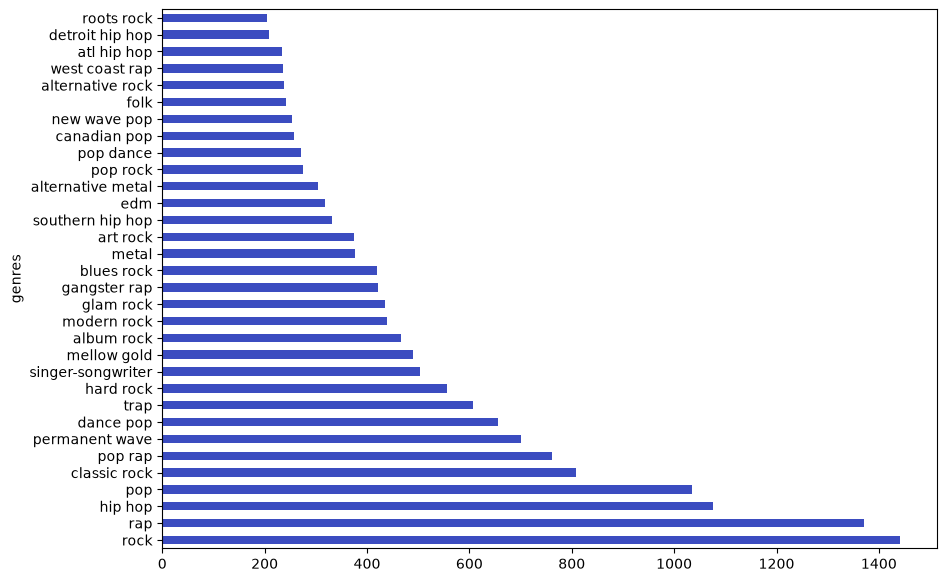

In [189]:
plt.figure(figsize=(10,7))
genres_counts[genres_counts>200].plot(kind='barh',colormap='coolwarm')

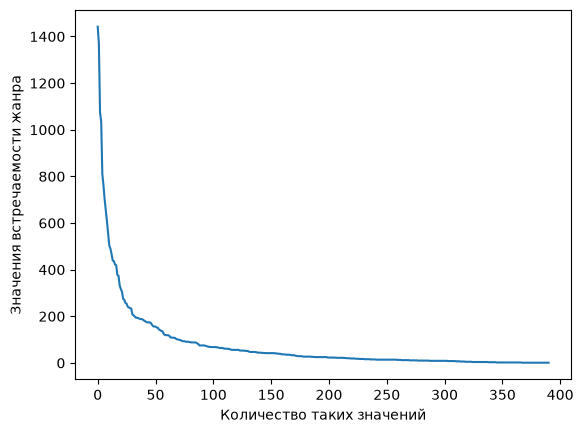

In [190]:
plt.plot(genres_counts.values)
plt.xlabel('Количество таких значений')
plt.ylabel('Значения встречаемости жанра')
plt.show()

In [191]:
top100 = genres_counts.head(100)
top100

genres
rock                1442
rap                 1370
hip hop             1076
pop                 1035
classic rock         809
                    ... 
louisville indie      71
dmv rap               69
reggae fusion         69
francoton             68
french hip hop        68
Name: count, Length: 100, dtype: int64

In [192]:
# выбираем только топ 100 жанров по встречаемсоти
top100.to_csv('data/genres_top.csv')

## Анализ артистов

In [193]:
df[df['artists'].str.contains(',')]

,song_id,artist_id,song,artists,explicit,genres,lyrics
13,spotify:track:1pNhY2t3jiVv9cEuJEHlia,spotify:artist:0GOx72r5AAEKRGQFn3xqXK,Oats,"['GIMS', {'label': 'spotify:artist:3i2AdhSP4Ye...",False,francoton;french hip hop;french pop;rap conscient,OATS Lyrics Yeah yeah Yeah yeah Yeah yeah J...
20,spotify:track:3xrYWpqTNDL1shQTs5LPtq,spotify:artist:4P0dddbxPil35MNN9G2MEX,Audio X,"['Cypress Hill', {'label': 'spotify:artist:7zs...",True,chicano rap;gangster rap;hardcore hip hop;hip ...,"Audio X Lyrics""T-Minus 10 9 8 7 6.. 5 4 ..."
35,spotify:track:23ao5xmZllnMj5OSEYN7cp,spotify:artist:6BrvowZBreEkXzJQMpL174,Nothing Can Hold Us Down,"['Hardwell', {'label': 'spotify:artist:6C0KWmC...",False,big room;dance pop;dutch house;edm;electro hou...,Nothing Can Hold Us Down Lyrics Oceans' red is...
37,spotify:track:4Zj3K3UaUMC6ndSwl05Zyd,spotify:artist:1vyhD5VmyZ7KMfW5gqLgo5,Bellacon,"['J Balvin', {'label': 'spotify:artist:2oQX8Qi...",False,reggaeton;reggaeton colombiano;urbano latino,Bellacon Lyrics Tú me tienes bellacón bellacó...
66,spotify:track:7jDkOdfBy7D5MJVKCxQQ2J,spotify:artist:17lzZA2AlOHwCwFALHttmp,Extremely Blessed,"['2 Chainz', {'label': 'spotify:artist:1W3FSF1...",True,atl hip hop;gangster rap;hip hop;pop rap;rap;s...,Extremely Blessed Lyrics Baby let's roll away ...
...,...,...,...,...,...,...,...
8632,spotify:track:1Lim1Py7xBgbAkAys3AGAG,spotify:artist:738wLrAtLtCtFOLvQBXOXp,Lean On,"['Major Lazer', {'label': 'spotify:artist:540v...",False,dance pop;edm;electro house;moombahton;pop;pop...,Translations Português Français Ελληνικά Lean ...
8648,spotify:track:13Mh55MPFYy2O6uby9061n,spotify:artist:55Aa2cqylxrFIXC767Z865,Shoot Me Down,"['Lil Wayne', {'label': 'spotify:artist:0SINQM...",True,hip hop;new orleans rap;pop rap;rap;trap,Shoot Me Down Lyrics Open up your hearts peop...
8654,spotify:track:0ZelN6FXKczKZQidKpOLAq,spotify:artist:22bukBZvUppuwQwmDz75Gz,Eagles,"['Sander van Doorn', {'label': 'spotify:artist...",False,dutch trance;edm;electro house;house;pop dance...,Eagles Lyrics Eager like fever burning when I...
8659,spotify:track:7Dclmopi4DlzmMqVEyHzG8,spotify:artist:6PAt558ZEZl0DmdXlnjMgD,I Feel Free,"['Eric Clapton', {'label': 'spotify:artist:74o...",False,blues rock;classic rock;electric blues;rock,I Feel Free Lyrics Feel when I dance with you ...


## Анализ языка текста

In [194]:
df[df['lyrics'].str.len()==0]

,song_id,artist_id,song,artists,explicit,genres,lyrics


In [195]:
from langdetect import detect

In [196]:
languages = df['lyrics'].apply(lambda x: detect(str(x)))

<Axes: xlabel='lyrics'>

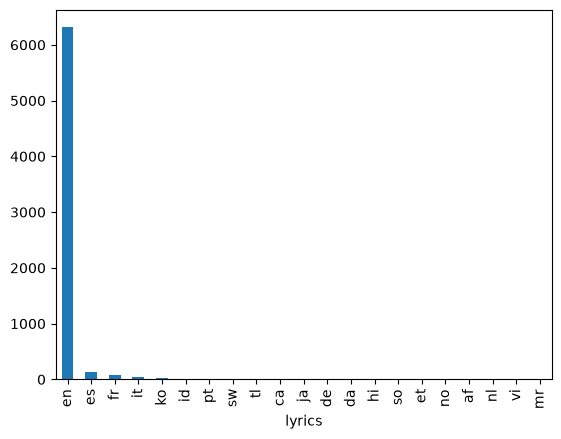

In [197]:
languages.value_counts().plot(kind='bar')

<Axes: xlabel='lyrics'>

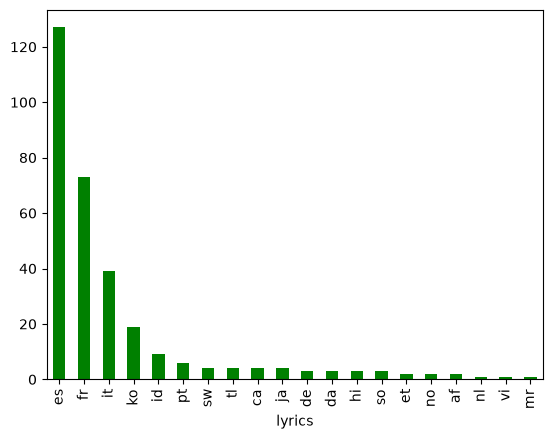

In [198]:
languages[languages!='en'].value_counts().plot(kind='bar', color='green')

In [199]:
set(languages)

{'af',
 'ca',
 'da',
 'de',
 'en',
 'es',
 'et',
 'fr',
 'hi',
 'id',
 'it',
 'ja',
 'ko',
 'mr',
 'nl',
 'no',
 'pt',
 'so',
 'sw',
 'tl',
 'vi'}

In [200]:
df[languages!='en']

,song_id,artist_id,song,artists,explicit,genres,lyrics
13,spotify:track:1pNhY2t3jiVv9cEuJEHlia,spotify:artist:0GOx72r5AAEKRGQFn3xqXK,Oats,"['GIMS', {'label': 'spotify:artist:3i2AdhSP4Ye...",False,francoton;french hip hop;french pop;rap conscient,OATS Lyrics Yeah yeah Yeah yeah Yeah yeah J...
37,spotify:track:4Zj3K3UaUMC6ndSwl05Zyd,spotify:artist:1vyhD5VmyZ7KMfW5gqLgo5,Bellacon,"['J Balvin', {'label': 'spotify:artist:2oQX8Qi...",False,reggaeton;reggaeton colombiano;urbano latino,Bellacon Lyrics Tú me tienes bellacón bellacó...
39,spotify:track:0tH73cQ8wWggprTskasQqy,spotify:artist:5iksmHDN2qZQcgFfXqIXtT,Hasta Siempre Comandante,['Robert Wyatt'],False,art rock;british folk;canterbury scene;experim...,Hasta Siempre Comandante Lyrics Aprendimos a q...
53,spotify:track:3Fy8eG3j2aPZ47bOlUtYhM,spotify:artist:2hejA1Dkf8v8R0koF44FvW,Dos Caras,['Gera MX'],False,mexican hip hop;rap conciencia,Dos Caras Lyrics Ouhh haha no veo no siento ye...
79,spotify:track:65jQEJX36oXm7LLUbe5ISK,spotify:artist:0UWZUmn7sybxMCqrw9tGa7,Radio Elvis,['Juanes'],False,colombian pop;latin pop;mexican pop;rock en es...,Radio Elvis Lyrics Con tu piel sobre mi piel y...
...,...,...,...,...,...,...,...
8483,spotify:track:2U31dTDQT1nPRydCxGWRIG,spotify:artist:0GOx72r5AAEKRGQFn3xqXK,ONLY YOU,"['GIMS', {'label': 'spotify:artist:6t7U7sYlVCt...",False,francoton;french hip hop;french pop;rap conscient,ONLY YOU Lyrics Ah ah ah ah Ton départ m'a ...
8507,spotify:track:5EW1Rlt4Hqc4eEMnIn3tEB,spotify:artist:4boI7bJtmB1L3b1cuL75Zr,Ana,['Mon Laferte'],False,latin alternative,Ana Lyrics¡Ana! No huyas de mí¿Por qué Ana c...
8571,spotify:track:2ywkj6sjyVBmq46wgIgIlw,spotify:artist:4Ai0pGz6GhQavjzaRhPTvz,Shehnai,['DIVINE'],False,desi hip hop;desi trap;hindi hip hop,Translations Romanization Shehnai Lyricsज़िन्दग...
8604,spotify:track:1I77XVl7wCTxJFwbWsQodh,spotify:artist:4boI7bJtmB1L3b1cuL75Zr,La Trenza,['Mon Laferte'],False,latin alternative,La trenza Lyrics Tú eres distinta a todas las ...


In [201]:
df.shape

(6623, 7)

In [202]:
df = df[languages=='en']

In [203]:
df.shape

(6313, 7)

## Анализ текстов

In [204]:
df['chars_count'] = df['lyrics'].str.strip().str.len()
df['words_count'] = df['lyrics'].str.strip().str.split().str.len()

In [205]:
df[['chars_count','words_count']].isna().sum()

chars_count    0
words_count    0
dtype: int64

In [206]:
df[['chars_count','words_count']].min()

chars_count    20
words_count     2
dtype: int64

In [207]:
df[df['words_count']<10]

,song_id,artist_id,song,artists,explicit,genres,lyrics,chars_count,words_count
532,spotify:track:6oFOjRsUhNZbKf4s1wfY8i,spotify:artist:6Xgp2XMz1fhVYe7i6yNAax,Breathes,['Trippie Redd'],False,melodic rap;rap;trap,Breathes Lyrics*breathing*Embed,31,2
1973,spotify:track:7pESc0gHImlLIGVasUJyCI,spotify:artist:0SfsnGyD8FpIN4U4WCkBZ5,Desiderium 207,"['Armin van Buuren', {'label': 'spotify:artist...",False,dutch trance;edm;pop dance;progressive house;t...,Desiderium 207 Lyrics You might also like Embed,47,8
2987,spotify:track:57wo0nOkY5Wj2XtaLYk3LM,spotify:artist:5vSQUyT33qxr1xAX2Tkf3A,Treetop,['Clams Casino'],False,experimental hip hop;psychedelic hip hop,Treetop Lyrics Embed,20,3
3724,spotify:track:4Nybn0evFPjCX59rhYYpHz,spotify:artist:0SfsnGyD8FpIN4U4WCkBZ5,Desiderium 207,"['Armin van Buuren', {'label': 'spotify:artist...",False,dutch trance;edm;pop dance;progressive house;t...,Desiderium 207 Lyrics You might also like Embed,47,8
3851,spotify:track:30dAaj2XY6MvXzCA93hJG6,spotify:artist:5vSQUyT33qxr1xAX2Tkf3A,Waterfalls,['Clams Casino'],False,experimental hip hop;psychedelic hip hop,Waterfalls Lyrics Embed,23,3
4052,spotify:track:3bHGsq7NzkavkCAK3zEAUZ,spotify:artist:1Cs0zKBU1kc0i8ypK3B9ai,Sunshine,"['David Guetta', {'label': 'spotify:artist:1vC...",False,big room;dance pop;edm;pop;pop dance,Sunshine Lyrics You might also like Embed,41,7
5099,spotify:track:0cHUEfcA4ekTsHwRlYRpsp,spotify:artist:0AD4odMWVQ2wUSlgxOB5Rl,Star Cycle,['Jeff Beck'],False,album rock;art rock;blues rock;british blues;c...,Star Cycle Lyrics]You might also like Embed,43,7
5494,spotify:track:0M5AxY5F9qNQiriiItyhy5,spotify:artist:6Xgp2XMz1fhVYe7i6yNAax,Woooo,['Trippie Redd'],False,melodic rap;rap;trap,Woooo Lyrics*Wolf howling noises*1Embed,39,4
6356,spotify:track:7CcCDv8Pd91brlJISTEZlp,spotify:artist:67ea9eGLXYMsO2eYQRui3w,Batman,['The Who'],False,album rock;art rock;blues rock;british invasio...,Batman Lyrics Batman You might also like1Embed,46,7
6720,spotify:track:6sFD2jtKURCQyCsf3kGGMf,spotify:artist:2ycnb8Er79LoH2AsR5ldjh,God Willing,['Pet Shop Boys'],False,art pop;dance rock;europop;new romantic;new wa...,God Willing Lyrics You might also like Embed,44,8


In [208]:
df[['chars_count','words_count']].max()

chars_count    12261
words_count     2348
dtype: int64

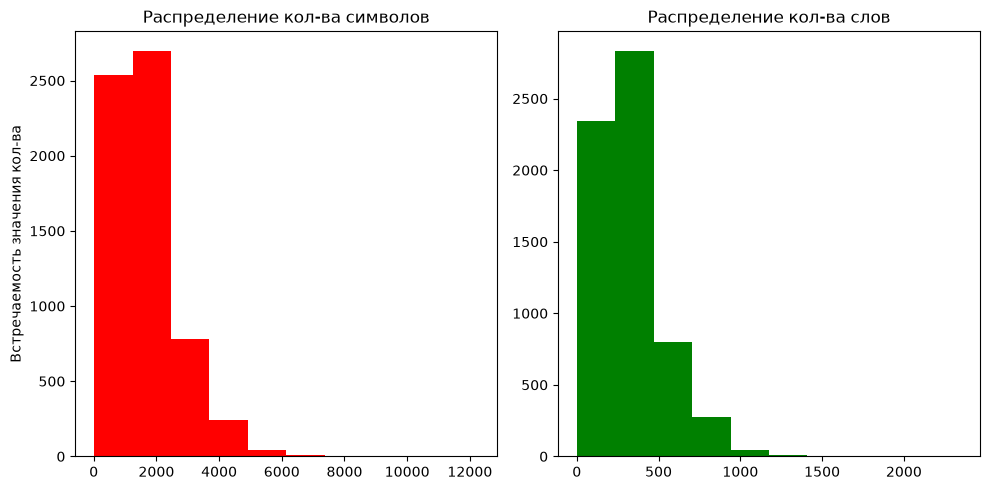

In [209]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].hist(df['chars_count'],color='red')
ax[0].set_title('Распределение кол-ва символов')
ax[0].set_ylabel('Встречаемость значения кол-ва')
ax[1].hist(df['words_count'],color='green')
ax[1].set_title('Распределение кол-ва слов')

plt.tight_layout()

In [210]:
df_genres = df[['genres','words_count']].copy()
df_genres['genres'] = df_genres['genres'].str.split(';')
df_genres=df_genres.explode('genres')

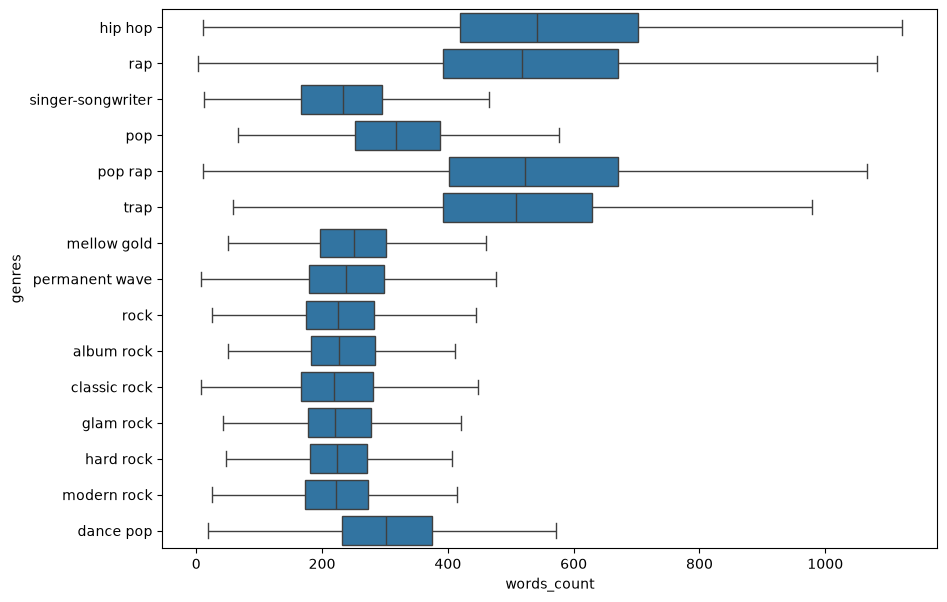

In [211]:
plt.figure(figsize=(10,7))
sns.boxplot(x='words_count',y='genres',data=df_genres[df_genres['genres'].isin(top100.head(15).index)],showfliers=False)
plt.show()

# Feature Engineering

In [248]:
df_final = df.copy()

In [249]:
df_final.drop(['words_count','chars_count'],axis=1,inplace=True)

## Очистка текстов песен

In [250]:
import re
def clean_lyrics(text):
    if not text:
        return ''
    text=re.sub(r'^.*Lyrics','',text)
    text=re.sub(r'You might also like','',text,flags=re.IGNORECASE)
    text=text.strip()
    text=re.sub(r'\d*Embed$','',text)
    return text.strip()

In [251]:
df_final['lyrics'] = df_final['lyrics'].apply(clean_lyrics)

In [258]:
df.sample()['lyrics']

684    Damage Lyrics Pluto Girl  I've been there for ...
Name: lyrics, dtype: str

In [260]:
df_final[df_final['lyrics'].str.contains('Pluto Girl')]['lyrics']

684    Pluto Girl  I've been there for you Pluto And ...
Name: lyrics, dtype: str

In [261]:
too_short_text_songs = df_final[df_final['lyrics'].str.split().str.len()<=50]['lyrics']
too_short_text_songs

184     Music for boys Music for boys Oh  yeah Oh  yea...
207     ...How I wish I could forget those happy yeste...
320     Yes  you done made it baby It's your boy Lil B...
354         I'm a candy kid I'm a candy kid Get up Get up
371     I gave you time Girl  you got my world upside ...
                              ...                        
7850    1 2 3 4!1 2 3 4!P1! Rocket Fuel Bang bang  off...
7881    Free speech  free speech for the dumb Free spe...
7943    I GOT RHYTHMI GOT MUSICI GOT MY MANWHO COULD A...
8196    Silhouette Of yourself Reverse Never ends Silh...
8264    Every knee shall bow Every tongue confess Jesu...
Name: lyrics, Length: 85, dtype: str

In [262]:
too_short_text_songs.shape

(85,)

In [263]:
df_final = df_final[df_final['lyrics'].str.split().str.len()>50]

## Обработка мультижанровости песни

In [264]:
df_final['genres'] = df_final['genres'].apply(lambda x: [genre.strip() for genre in str(x).strip().split(';') if genre.strip()])
df_final.head()

,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,['Beth Hart'],False,[modern blues],I can feel my body breathing I can feel my hea...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,['Cypress Hill'],True,"[chicano rap, gangster rap, hardcore hip hop, ...",Some people tell me that I need help Some peop...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,['Brandi Carlile'],False,"[acoustic pop, folk, indie pop, lilith, modern...",I swear when we touched I saw heaven in your ...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,['Big Sean'],True,"[detroit hip hop, hip hop, pop, pop rap, rap, ...",Nothing is stopping you Stopping you Stopping ...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,['Sheryl Crow'],False,"[lilith, mellow gold, neo mellow, new wave pop...",Come to me now And lay your hands over me Even...


## Обработка случае нескольких исполнителей у песни

In [265]:
df_final['artists'] = df_final['artists'].apply(lambda x: [artist.strip() for artist in str(x).replace('[','').replace(']','').replace("'",'').strip().split(',') if artist.strip()])
df_final.head()

,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,[Beth Hart],False,[modern blues],I can feel my body breathing I can feel my hea...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,[Cypress Hill],True,"[chicano rap, gangster rap, hardcore hip hop, ...",Some people tell me that I need help Some peop...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,[Brandi Carlile],False,"[acoustic pop, folk, indie pop, lilith, modern...",I swear when we touched I saw heaven in your ...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,[Big Sean],True,"[detroit hip hop, hip hop, pop, pop rap, rap, ...",Nothing is stopping you Stopping you Stopping ...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,[Sheryl Crow],False,"[lilith, mellow gold, neo mellow, new wave pop...",Come to me now And lay your hands over me Even...


In [266]:
df_final

,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,[Beth Hart],False,[modern blues],I can feel my body breathing I can feel my hea...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,[Cypress Hill],True,"[chicano rap, gangster rap, hardcore hip hop, ...",Some people tell me that I need help Some peop...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,[Brandi Carlile],False,"[acoustic pop, folk, indie pop, lilith, modern...",I swear when we touched I saw heaven in your ...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,[Big Sean],True,"[detroit hip hop, hip hop, pop, pop rap, rap, ...",Nothing is stopping you Stopping you Stopping ...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,[Sheryl Crow],False,"[lilith, mellow gold, neo mellow, new wave pop...",Come to me now And lay your hands over me Even...
...,...,...,...,...,...,...,...
8666,spotify:track:3XDl09T6fty3xbGSXASLT8,spotify:artist:43O3c6wewpzPKwVaGEEtBM,New Morning,[My Morning Jacket],False,"[alternative rock, blues rock, indie folk, ind...",Wakin' up feelin' good and limber When the tel...
8668,spotify:track:6JbioaahWqp3efRZWN001d,spotify:artist:00FQb4jTyendYWaN8pK0wa,Bel Air,[Lana Del Rey],False,"[art pop, pop]",Gargoyles standing at the front of your gate T...
8670,spotify:track:1yKLa9X63tBfvLojNOw9y8,spotify:artist:50co4Is1HCEo8bhOyUWKpn,Harambe,[Young Thug],True,"[atl hip hop, atl trap, gangster rap, hip hop,...",Mafia Billboard Hitmakers Yeah AP gang bitch...
8672,spotify:track:64kfyGcf5dvbw92Vv4THCj,spotify:artist:0C8ZW7ezQVs4URX5aX7Kqx,Fun,[Selena Gomez],False,"[dance pop, pop, post-teen pop]",This is just what the doctor ordered Put a gol...


In [267]:
df_final['artists'] = df_final['artists'].apply(lambda x: [art for art in x if isinstance(art, str) and 'label' not in art])

In [268]:
df_final

,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,[Beth Hart],False,[modern blues],I can feel my body breathing I can feel my hea...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,[Cypress Hill],True,"[chicano rap, gangster rap, hardcore hip hop, ...",Some people tell me that I need help Some peop...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,[Brandi Carlile],False,"[acoustic pop, folk, indie pop, lilith, modern...",I swear when we touched I saw heaven in your ...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,[Big Sean],True,"[detroit hip hop, hip hop, pop, pop rap, rap, ...",Nothing is stopping you Stopping you Stopping ...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,[Sheryl Crow],False,"[lilith, mellow gold, neo mellow, new wave pop...",Come to me now And lay your hands over me Even...
...,...,...,...,...,...,...,...
8666,spotify:track:3XDl09T6fty3xbGSXASLT8,spotify:artist:43O3c6wewpzPKwVaGEEtBM,New Morning,[My Morning Jacket],False,"[alternative rock, blues rock, indie folk, ind...",Wakin' up feelin' good and limber When the tel...
8668,spotify:track:6JbioaahWqp3efRZWN001d,spotify:artist:00FQb4jTyendYWaN8pK0wa,Bel Air,[Lana Del Rey],False,"[art pop, pop]",Gargoyles standing at the front of your gate T...
8670,spotify:track:1yKLa9X63tBfvLojNOw9y8,spotify:artist:50co4Is1HCEo8bhOyUWKpn,Harambe,[Young Thug],True,"[atl hip hop, atl trap, gangster rap, hip hop,...",Mafia Billboard Hitmakers Yeah AP gang bitch...
8672,spotify:track:64kfyGcf5dvbw92Vv4THCj,spotify:artist:0C8ZW7ezQVs4URX5aX7Kqx,Fun,[Selena Gomez],False,"[dance pop, pop, post-teen pop]",This is just what the doctor ordered Put a gol...


## Оставляем топ100 популярных жанров

In [269]:
df_final.shape

(6228, 7)

In [270]:
df_final = df_final[df_final['genres'].apply(lambda x: any(genre in genres_counts.head(100) for genre in x))]

In [271]:
df_final.shape

(5749, 7)

In [272]:
df_final['genres'] = df_final['genres'].apply(lambda x: [genre for genre in x if genre in top100])

# Финальный датасет

In [273]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 5749 entries, 1 to 8673
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   song_id    5749 non-null   str   
 1   artist_id  5749 non-null   str   
 2   song       5749 non-null   str   
 3   artists    5749 non-null   object
 4   explicit   5749 non-null   bool  
 5   genres     5749 non-null   object
 6   lyrics     5749 non-null   str   
dtypes: bool(1), object(2), str(4)
memory usage: 320.0+ KB


In [274]:
df_final

,song_id,artist_id,song,artists,explicit,genres,lyrics
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,[Cypress Hill],True,"[chicano rap, gangster rap, hardcore hip hop, ...",Some people tell me that I need help Some peop...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,[Brandi Carlile],False,"[folk, indie pop, lilith, neo mellow, new amer...",I swear when we touched I saw heaven in your ...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,[Big Sean],True,"[detroit hip hop, hip hop, pop, pop rap, rap, ...",Nothing is stopping you Stopping you Stopping ...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,[Sheryl Crow],False,"[lilith, mellow gold, neo mellow, new wave pop...",Come to me now And lay your hands over me Even...
5,spotify:track:6QhsQvMgEuqJE6z7re1ijE,spotify:artist:3EhbVgyfGd7HkpsagwL9GS,Why Trust You,[Alice Cooper],False,"[album rock, blues rock, classic rock, detroit...",You come on strong with a great big smile But ...
...,...,...,...,...,...,...,...
8666,spotify:track:3XDl09T6fty3xbGSXASLT8,spotify:artist:43O3c6wewpzPKwVaGEEtBM,New Morning,[My Morning Jacket],False,"[alternative rock, blues rock, indie folk, ind...",Wakin' up feelin' good and limber When the tel...
8668,spotify:track:6JbioaahWqp3efRZWN001d,spotify:artist:00FQb4jTyendYWaN8pK0wa,Bel Air,[Lana Del Rey],False,"[art pop, pop]",Gargoyles standing at the front of your gate T...
8670,spotify:track:1yKLa9X63tBfvLojNOw9y8,spotify:artist:50co4Is1HCEo8bhOyUWKpn,Harambe,[Young Thug],True,"[atl hip hop, gangster rap, hip hop, melodic r...",Mafia Billboard Hitmakers Yeah AP gang bitch...
8672,spotify:track:64kfyGcf5dvbw92Vv4THCj,spotify:artist:0C8ZW7ezQVs4URX5aX7Kqx,Fun,[Selena Gomez],False,"[dance pop, pop, post-teen pop]",This is just what the doctor ordered Put a gol...


In [275]:
import csv

In [276]:
df_final[['song','artists','lyrics','genres']].to_csv('data/final_kaggle_dataset.csv',index=False,encoding='utf-8',escapechar="\\",quoting=csv.QUOTE_MINIMAL)